## Machine Learning Model Creation

In [14]:
import pandas as pd
df = pd.read_csv(r"clean_data.csv")
df.head()

,area_sqft,rooms,build_year,location,street_type,furnishing,property_type,has_pool,price
0,2473.192784,4,1992,jaipur,residential lane,furnished,apartment,0,568486.0
1,2353.472711,4,2006,indore,corner plot,unfurnished,apartment,1,577214.0
2,2212.222005,3,2012,jaipur,highway facing,semi-furnished,duplex,0,581300.0
3,2823.886596,6,1993,lucknow,main road,unfurnished,villa,1,794614.0
4,1869.648721,5,2012,jaipur,corner plot,semi-furnished,apartment,0,493086.0


In [15]:
(df['price'] > 1000000).sum()

np.int64(9)

In [16]:
df = df[df['price']<1000000]

In [17]:
furnishing_map = {'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2}
df['furnishing'] = df['furnishing'].map(furnishing_map)

In [18]:
df = pd.get_dummies(df, columns=['location', 'street_type', 'property_type'], drop_first=True)

In [19]:
from sklearn.preprocessing import StandardScaler
from datetime import datetime

current_year = datetime.now().year
df['house_age'] = current_year - df['build_year']
df = df.drop(columns=['build_year'])

y = df['price']
X = df.drop(columns=['price'])

cols_to_scale = ['area_sqft', 'rooms', 'house_age']
scaler = StandardScaler()
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier,plot_tree
import matplotlib.pyplot as plt

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

In [22]:
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Linear Regression Model Performance ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R²): {r2:.4f}\n")

--- Linear Regression Model Performance ---
Mean Absolute Error (MAE): $14,468.99
Root Mean Squared Error (RMSE): $18,119.62
R-squared (R²): 0.9769



## Explanation:

After training the Multiple Linear Regression model on our engineered and scaled dataset, the results indicate a highly accurate and reliable predictive system.

**R-squared (R²): 0.9769**
The model successfully explains 97.7% of the variance in housing prices. This exceptionally high score demonstrates that our selected features (square footage, rooms, house age, and location) are remarkably strong predictors of a property's final market value.

**Mean Absolute Error (MAE): $14,468.99**
On average, the model's price estimates deviate from the actual sale price by roughly 14,500 USD. In the context of real estate valuations—where properties cost hundreds of thousands of dollars—this represents a very tight and reliable margin of error.

**Root Mean Squared Error (RMSE): $18,119.62**
The RMSE is closely aligned with the MAE, validating our earlier EDA strategy. Because RMSE heavily penalizes massive prediction errors, this low figure confirms that removing the extreme luxury outliers (properties > USD 1,000,000) successfully protected the model. The algorithm is highly consistent and does not suffer from wild, inaccurate predictions on edge cases.

**Final Takeaway:** The Multiple Linear Regression baseline provides robust, production-ready accuracy for standard residential homes, making it highly suitable for an Automated Valuation Model (AVM) pipeline.

## What I Did:

1. Mapped furnishing data properly.
2. Made dummy variables for Furnishing Data.
3. Scaled the Data.
4. Handled outliers
5. Trained a linear regression model.

# Next Model: KNN

In [23]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
knn_model = KNeighborsRegressor(n_neighbors=5, weights='distance')
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("\n--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")


--- Model Evaluation ---
Mean Absolute Error (MAE): $14,468.99
Root Mean Squared Error (RMSE): $58,947.30
R-squared (R2) Score: 0.7552


## Explanation

**R2 Score:** The initial KNN Regressor achieved an $R^2$ score of 0.7552, indicating that the model successfully explains approximately 75.5% of the variance in housing prices.While the general predictive accuracy is strong, evaluating the error metrics reveals crucial insights into the dataset's distribution:

**Mean Absolute Error (MAE):** $14,468.99 On average, the model's predictions deviate from the actual sale price by roughly 14,500 USD. For standard residential real estate estimation, this represents a reliable baseline error margin.

**Root Mean Squared Error (RMSE):** $58,947.30 The significant disparity between the MAE and the RMSE highlights the presence of extreme outliers in the dataset. Because RMSE heavily penalizes larger errors, this inflation suggests the model struggles to accurately price edge-case properties (e.g., ultra-luxury homes or unique structural outliers) using spatial distance alone.

## Decision Tree:

In [25]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
dt_model = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print("\n--- Decision Tree Evaluation ---")
print(f"Mean Absolute Error (MAE): ${mae_dt:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse_dt:,.2f}")
print(f"R-squared (R2) Score: {r2_dt:.4f}")


--- Decision Tree Evaluation ---
Mean Absolute Error (MAE): $56,801.43
Root Mean Squared Error (RMSE): $71,817.75
R-squared (R2) Score: 0.6367


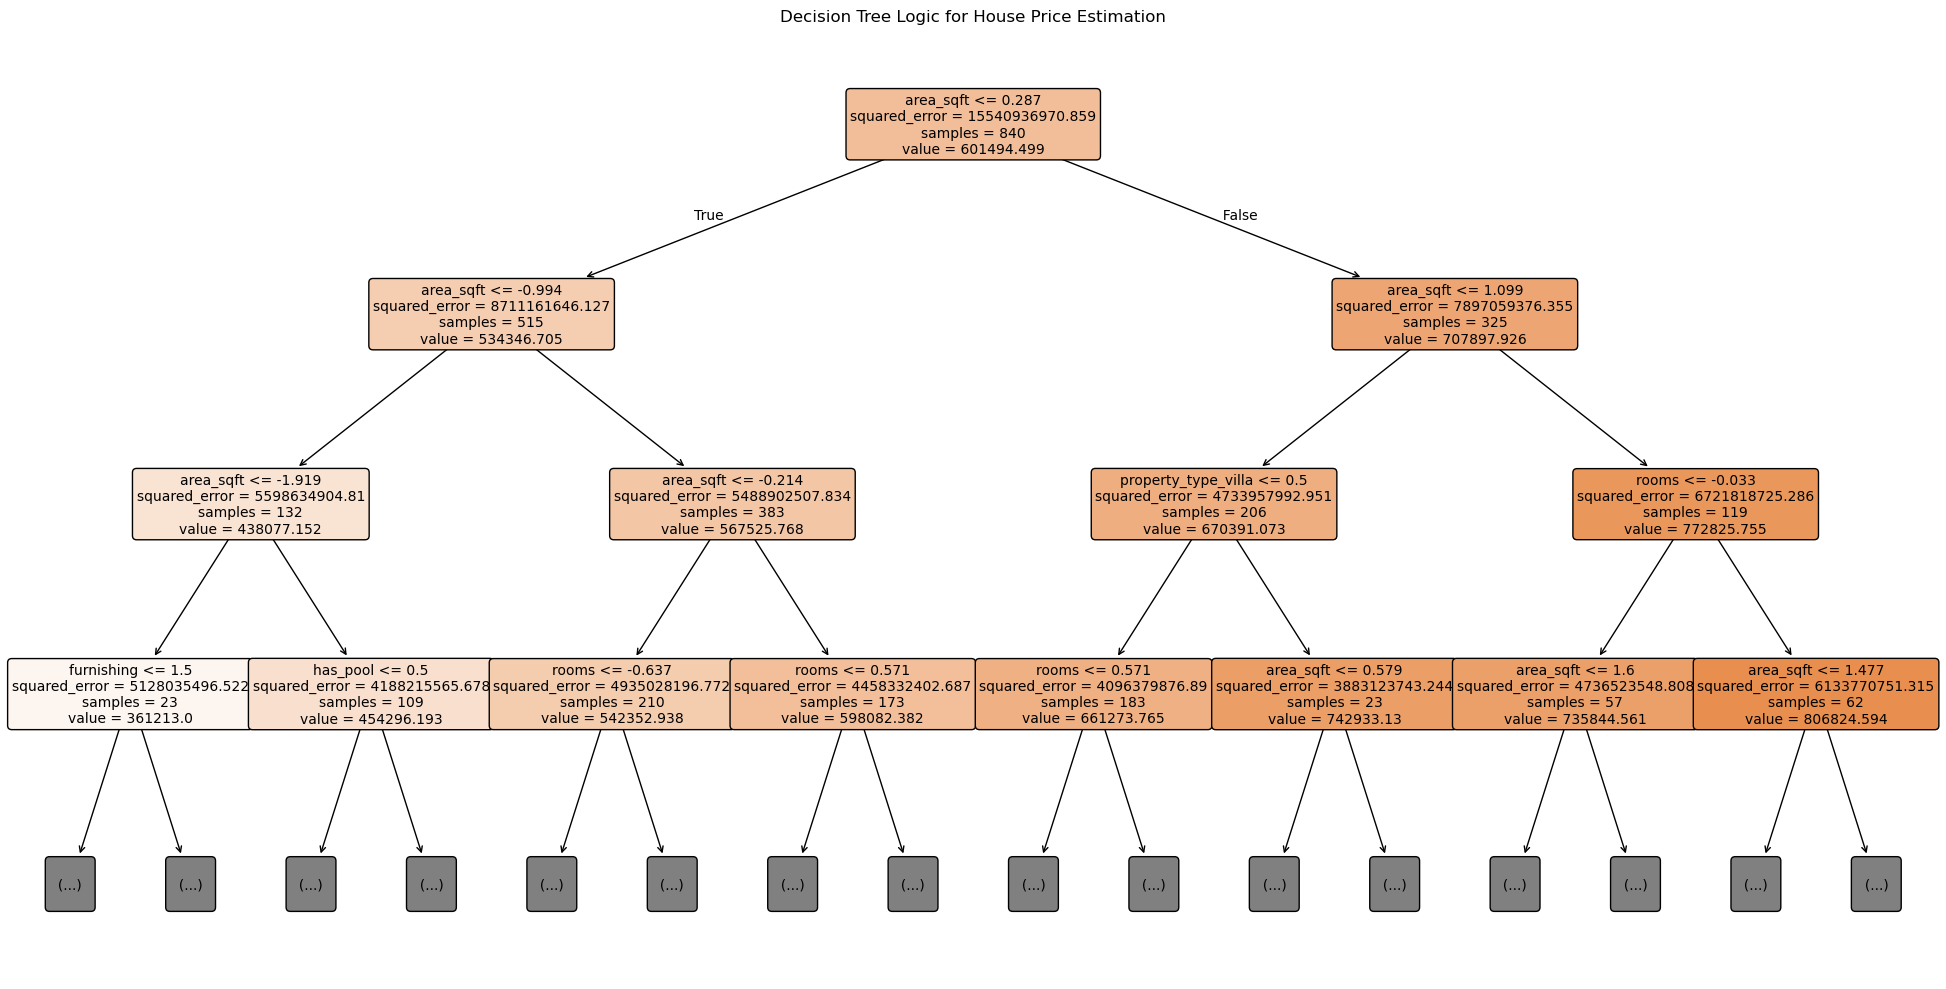

In [26]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          feature_names=X_train.columns, 
          filled=True, 
          rounded=True, 
          fontsize=10, 
          max_depth=3) 
plt.title("Decision Tree Logic for House Price Estimation")
plt.tight_layout()
plt.show()

To understand exactly how the DecisionTreeRegressor arrives at its price estimates, we can visualize the top layers of the model's decision-making process. Unlike black-box algorithms, a Decision Tree provides transparent, conditional logic, allowing us to see exactly how different features influence the final valuation.

By analyzing the decision pathways (truncated here to a depth of 3 for readability), we can extract several key insights about the local real estate market and our dataset:

**Primary Predictor (The Root Node):** The model definitively identified square footage (area_sqft) as the most critical factor in determining a house's price. The tree uses this scaled feature for the initial root split, as well as the majority of the secondary splits, to immediately segment properties into major price tiers.

**Effective Feature Engineering:** As the tree deepens into the third level, it begins utilizing the categorical dummy variables created during preprocessing. Features like property_type_villa, has_pool, and furnishing are actively used to refine prices, proving that these structural and lifestyle features hold distinct mathematical weight in the market.

**Variance Reduction in Action:** At every step, the model seeks to minimize the Mean Squared Error (squared_error). The root node begins with the dataset's global average price of ~$601,494. By systematically routing properties through the conditional splits, the tree successfully isolates distinct property profiles—arriving at targeted leaf nodes that range from highly depreciated or smaller homes (valued around ~361,000 USD) to premium, large-scale properties (valued over ~806,000 USD).

**Conclusion on Tree Logic:** This visualization confirms that the model is making logical, real-world pricing deductions. It correctly prioritizes sheer size first, and then fine-tunes the estimate based on specific amenities and property types, making it a highly interpretable and reliable baseline for the interactive estimation system.